In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('data/LengthOfStay.csv')

# See how many rows and columns we have
print(f"Dataset shape: {df.shape}")

# Look at the first 5 rows
df.head()

Dataset shape: (100000, 28)


,eid,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,...,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,lengthofstay
0,1,8/29/2012,0,F,0,0,0,0,0,0,...,192.476918,12.0,1.390722,30.432418,96,6.5,4,9/1/2012,B,3
1,2,5/26/2012,5+,F,0,0,0,0,0,0,...,94.078507,8.0,0.943164,28.460516,61,6.5,1,6/2/2012,A,7
2,3,9/22/2012,1,F,0,0,0,0,0,0,...,130.530524,12.0,1.065750,28.843812,64,6.5,2,9/25/2012,B,3
3,4,8/9/2012,0,F,0,0,0,0,0,0,...,163.377028,12.0,0.906862,27.959007,76,6.5,1,8/10/2012,A,1
4,5,12/20/2012,0,F,0,0,0,1,0,1,...,94.886654,11.5,1.242854,30.258927,67,5.6,2,12/24/2012,E,4


--- Missing Values ---
0

--- Length of Stay Stats ---
count    100000.00000
mean          4.00103
std           2.36031
min           1.00000
25%           2.00000
50%           4.00000
75%           6.00000
max          17.00000
Name: lengthofstay, dtype: float64


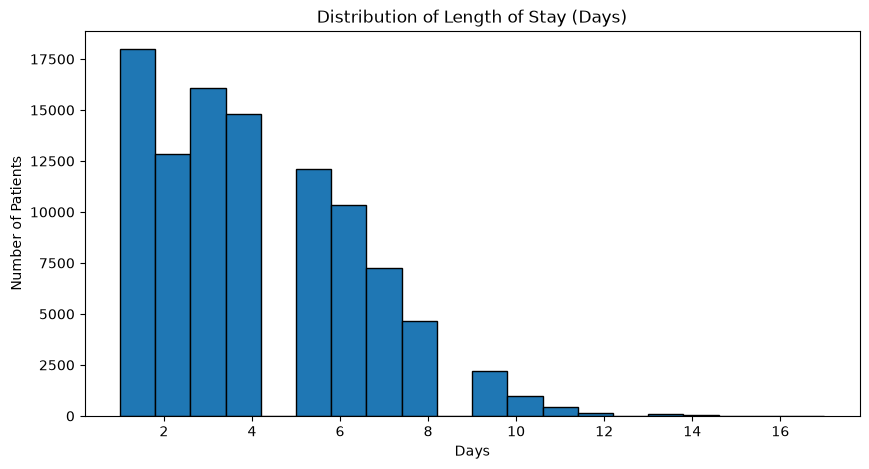

In [4]:
# 1. Check for missing values
print("--- Missing Values ---")
print(df.isnull().sum().max()) # Just checking the max missing to keep output short. If > 0, we'll dig deeper.

# 2. Basic statistics for Length of Stay
print("\n--- Length of Stay Stats ---")
print(df['lengthofstay'].describe())

# 3. Plot the distribution of Length of Stay
plt.figure(figsize=(10, 5))
plt.hist(df['lengthofstay'], bins=20, edgecolor='black')
plt.title('Distribution of Length of Stay (Days)')
plt.xlabel('Days')
plt.ylabel('Number of Patients')
plt.show()

In [5]:
# 1. Drop ID and Leaky columns
# We drop 'discharged' to prevent data leakage.
df_clean = df.drop(columns=['eid', 'vdate', 'discharged'])

# 2. Machine learning models only understand numbers. 
# Let's find which columns are currently text/categories (objects).
text_columns = df_clean.dtypes[df_clean.dtypes == 'object']
print("Columns that need to be converted to numbers:")
print(text_columns)

Columns that need to be converted to numbers:
Series([], dtype: object)


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Just to be 100% safe, pd.get_dummies will quietly encode any hidden text columns
df_model = pd.get_dummies(df_clean, drop_first=True)

# 2. Separate our Features (X) from our Target (y)
X = df_model.drop(columns=['lengthofstay'])
y = df_model['lengthofstay']

# 3. Split the data: 80% for the model to learn from (train), 20% to test it on (test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and Train the simple Linear Regression model
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

# 5. Make predictions on the unseen test data
y_pred = baseline_model.predict(X_test)

# 6. Calculate our evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Baseline MAE (Mean Absolute Error): {mae:.2f} days")
print(f"Baseline RMSE (Root Mean Squared Error): {rmse:.2f} days")
print(f"Baseline R-squared: {r2:.3f}")

Baseline MAE (Mean Absolute Error): 0.87 days
Baseline RMSE (Root Mean Squared Error): 1.13 days
Baseline R-squared: 0.768


In [7]:
from sklearn.ensemble import RandomForestRegressor

# 1. Initialize the Random Forest model
# n_jobs=-1 tells it to use all your CPU cores to train faster
# max_depth=10 prevents the model from memorizing the training data (overfitting)
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)

# 2. Train the model
print("Training Random Forest... this might take 10-30 seconds.")
rf_model.fit(X_train, y_train)

# 3. Make predictions on the test data
y_pred_rf = rf_model.predict(X_test)

# 4. Calculate metrics to see if it beat our baseline
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest MAE: {mae_rf:.2f} days")
print(f"Random Forest RMSE: {rmse_rf:.2f} days")
print(f"Random Forest R-squared: {r2_rf:.3f}")

Training Random Forest... this might take 10-30 seconds.
Random Forest MAE: 0.77 days
Random Forest RMSE: 1.00 days
Random Forest R-squared: 0.817


--- Top 10 Most Important Features ---
rcount_5+      0.210657
rcount_4       0.196695
rcount_3       0.147346
facid_E        0.135101
rcount_2       0.107190
hematocrit     0.039175
hemo           0.031598
rcount_1       0.025743
irondef        0.024107
respiration    0.021384
dtype: float64


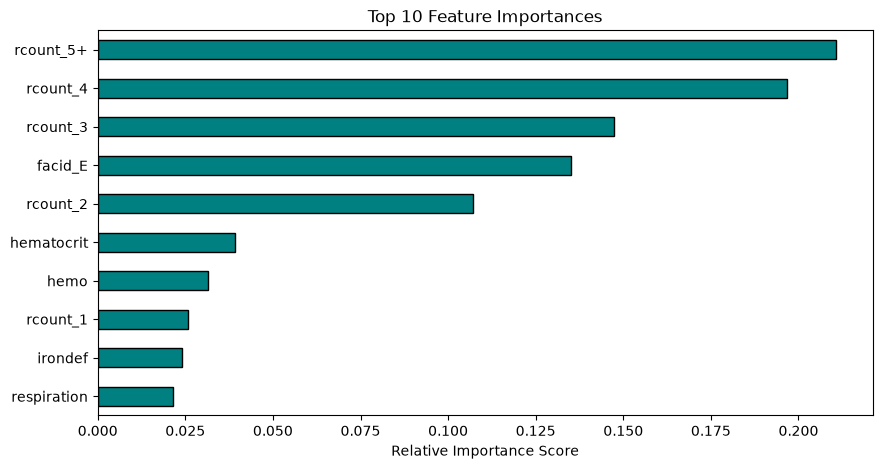

In [8]:
# 1. Extract feature importances from the Random Forest model
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top_10 = importances.nlargest(10)

print("--- Top 10 Most Important Features ---")
print(top_10)

# 2. Plot the top 10 features
plt.figure(figsize=(10, 5))
top_10.sort_values().plot(kind='barh', color='teal', edgecolor='black')
plt.title('Top 10 Feature Importances')
plt.xlabel('Relative Importance Score')
plt.show()

In [9]:
# Group by the original facility column to see the average stay and number of patients
facility_stats = df_clean.groupby('facid')['lengthofstay'].agg(['mean', 'count'])
print(facility_stats)

           mean  count
facid                 
A      3.270551  30035
B      3.283953  30012
C      4.890402   4699
D      4.827962   4499
E      5.157308  30755


In [10]:
!pip install shap

     ---------------------------------------- 0.0/57.4 kB ? eta -:--:--
     ------- -------------------------------- 10.2/57.4 kB ? eta -:--:--
     --------------------------------- ---- 51.2/57.4 kB 871.5 kB/s eta 0:00:01
     -------------------------------------- 57.4/57.4 kB 748.0 kB/s eta 0:00:00
   ---------------------------------------- 0.0/554.9 kB ? eta -:--:--
   -- ------------------------------------- 30.7/554.9 kB 1.4 MB/s eta 0:00:01
   ----- ---------------------------------- 81.9/554.9 kB 1.5 MB/s eta 0:00:01
   ---------- ----------------------------- 143.4/554.9 kB 1.2 MB/s eta 0:00:01
   -------------- ------------------------- 194.6/554.9 kB 1.1 MB/s eta 0:00:01
   -------------- ----------------------- 204.8/554.9 kB 892.5 kB/s eta 0:00:01
   ----------------- -------------------- 256.0/554.9 kB 927.4 kB/s eta 0:00:01
   --------------------- ---------------- 307.2/554.9 kB 951.8 kB/s eta 0:00:01
   --------------------------- ------------ 378.9/554.9 kB 1.0 MB/


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


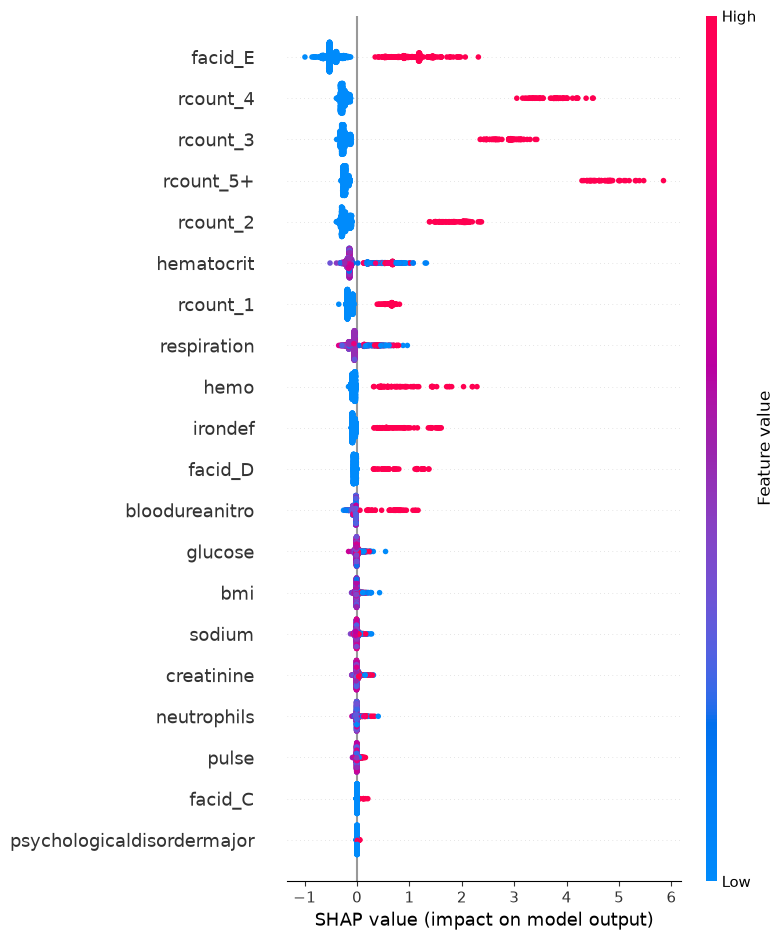

In [11]:
import shap

# 1. SHAP is computationally heavy, so we take a random sample of 1,000 patients from our test set
X_test_sample = X_test.sample(n=1000, random_state=42)

# 2. Create the SHAP explainer using our trained Random Forest model
explainer = shap.TreeExplainer(rf_model)

# 3. Calculate the SHAP values (this might take a few seconds)
shap_values = explainer.shap_values(X_test_sample)

# 4. Plot the SHAP summary
shap.summary_plot(shap_values, X_test_sample)

In [12]:
# 1. Create a DataFrame comparing actual stays to our model's predictions
results = pd.DataFrame({
    'Actual_LOS': y_test,
    'Predicted_LOS': y_pred_rf
})

# 2. Calculate the absolute error (how many days off we were)
results['Error'] = abs(results['Actual_LOS'] - results['Predicted_LOS'])

# 3. Sort by the biggest errors to see where the model was most confused
worst_predictions = results.sort_values(by='Error', ascending=False)

print("--- Top 5 Worst Predictions ---")
print(worst_predictions.head())

--- Top 5 Worst Predictions ---
       Actual_LOS  Predicted_LOS     Error
14556          10       1.666591  8.333409
80864           8       1.666591  6.333409
62258           8       1.666591  6.333409
96850           8       1.666591  6.333409
74141           8       1.666591  6.333409


In [13]:
import joblib

# 1. Save the trained Random Forest model to a file
joblib.dump(rf_model, 'rf_model.joblib')

# 2. Save the exact list of feature columns the model expects
joblib.dump(list(X_train.columns), 'model_features.joblib')

print("Model and features saved successfully!")

Model and features saved successfully!
